# Data Understanding and Exploratory Data Analysis (EDA)

## Project
AI Recruitment Guardian: An Explainable Machine Learning Framework for Fake Job Detection and Risk Assessment

### Objectives
- Understand the structure of the EMSCAD dataset.
- Analyze feature types and missing values.
- Study class distribution.
- Explore text and categorical features.
- Identify potential preprocessing requirements.

In [1]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\hp\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

print("All libraries imported successfully! ✅")

All libraries imported successfully! ✅


In [3]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Analysis
from wordcloud import WordCloud
from collections import Counter

# Notebook Settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Display all columns
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)


In [6]:
df = pd.read_csv("../data/raw/fake_job_postings.csv")
df.head()
print("Shape of Dataset:", df.shape)
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])
df.head()
df.tail()
df.sample(5, random_state=42)
df.info()
df.columns

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

df.describe(include="object")

Shape of Dataset: (17880, 18)
Number of Rows : 17880
Number of Columns : 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 

,title,location,department,salary_range,company_profile,description,requirements,benefits,employment_type,required_experience,required_education,industry,function
count,17880,17534,6333,2868,14572,17879,15184,10668,14409,10830,9775,12977,11425
unique,11231,3105,1337,874,1709,14801,11967,6204,5,7,13,131,37
top,English Teacher Abroad,"GB, LND, London",Sales,0-0,We help teachers get safe &amp; secure jobs abroad :),"Play with kids, get paid for it Love travel? Jobs in Asia$1,500+ USD monthly ($200 Cost of livin...",University degree required. TEFL / TESOL / CELTA or teaching experience preferred but not necess...,See job description,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology
freq,311,718,551,142,726,379,410,726,11620,3809,5145,1734,1749


In [7]:
# Count missing values
missing_values = df.isnull().sum()

# Percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a report
missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

# Sort by highest missing percentage
missing_df = missing_df.sort_values(by="Missing Percentage", ascending=False)

missing_df

,Missing Values,Missing Percentage
salary_range,15012,83.959732
department,11547,64.580537
required_education,8105,45.329978
benefits,7212,40.335570
required_experience,7050,39.429530
function,6455,36.101790
industry,4903,27.421700
employment_type,3471,19.412752
company_profile,3308,18.501119
requirements,2696,15.078300


C:\Users\hp\AppData\Local\Temp\ipykernel_22400\2194852671.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


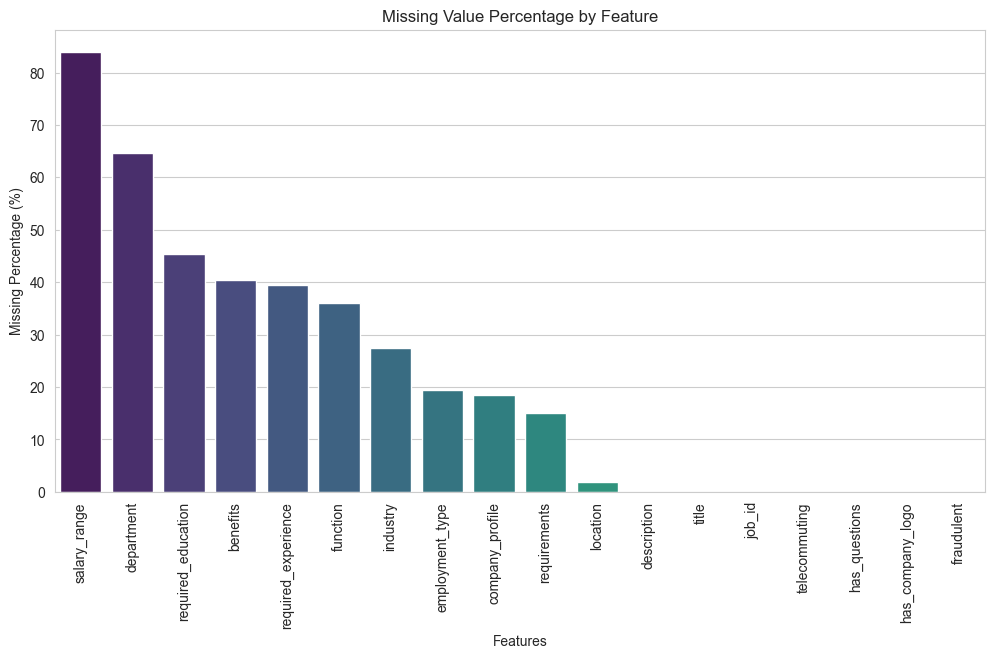

In [8]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=missing_df.index,
    y=missing_df["Missing Percentage"],
    palette="viridis"
)

plt.xticks(rotation=90)

plt.ylabel("Missing Percentage (%)")

plt.xlabel("Features")

plt.title("Missing Value Percentage by Feature")

plt.show()